### Importación de datos



In [42]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [72]:
# Obtener el ingreso total por cada tienda utilizando sum
print("Ingreso Total por cada Tienda")
print()
print("  Tienda: ", format(sum(tienda.Precio), ","), "  Tienda2: ", format(sum(tienda2.Precio), ","), "  Tienda3: ", format(sum(tienda3.Precio), ","), \
      "Tienda4: ", format(sum(tienda4.Precio), ","))

Ingreso Total por cada Tienda

  Tienda:  1,150,880,400.0   Tienda2:  1,116,343,500.0   Tienda3:  1,098,019,600.0 Tienda4:  1,038,375,700.0


In [26]:
# Obtener el ingreso neto por cada tienda, restando el coto de envio al precio
print()
print("Ingreso Total menos costo de envio por cada Tienda")
print()
# Cambiar en segundo sum Precio por Costo de envío df['col1'].sum()
print(f"Tienda: {sum(tienda.Precio) - tienda['Costo de envío'].sum():,.0f}   Tienda2: {sum(tienda2.Precio) - tienda2['Costo de envío'].sum():,.0f}    \
Tienda3: {sum(tienda3.Precio) - tienda3['Costo de envío'].sum():,.0f}    Tienda4: {sum(tienda4.Precio) - tienda4['Costo de envío'].sum():,.0f}")


Ingreso Total menos costo de envio por cada Tienda

Tienda: 1,089,502,500   Tienda2: 1,056,858,400    Tienda3: 1,039,503,000    Tienda4: 983,058,300


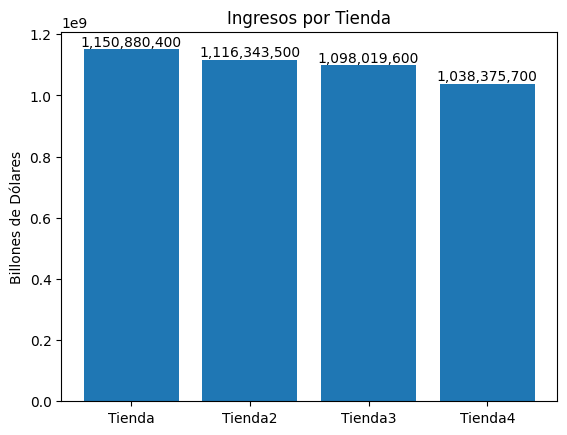

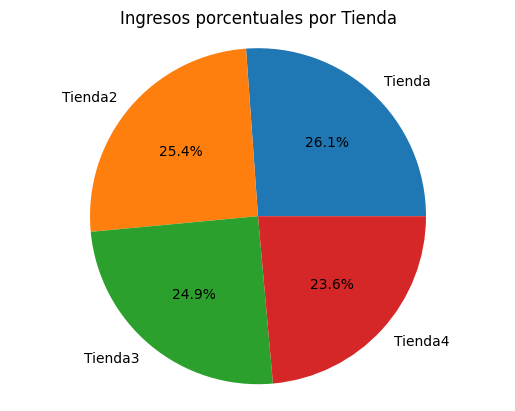

In [77]:
# Importar bibloteca para graficar
from matplotlib import pyplot as plt

# Gráfico de Barras para Ingreso Total por Tienda
# Crear DataFrame para almacenar valores a graficar
#tiendas = ["Tienda", "Tienda2", "Tienda3", "Tienda4"]
#ingresos = [sum(tienda.Precio), sum(tienda2.Precio), sum(tienda3.Precio), sum(tienda4.Precio)]
data = {'tiendas': ["Tienda", "Tienda2", "Tienda3", "Tienda4"],
        'ingresos': [sum(tienda.Precio), sum(tienda2.Precio), sum(tienda3.Precio), sum(tienda4.Precio)]}
df = pd.DataFrame(data)

# Añadir etiquetas
# plt.xlabel("Tiendas")
plt.ylabel("Billones de Dólares")
plt.title("Ingresos por Tienda")

# Seleccionar gráfico
plt.bar(df['tiendas'], df['ingresos'])

# Etiquetas en las barras con comas y sin decimales
for x, y in zip(df['tiendas'], df['ingresos']):
    #plt.text(x, y, str("%.0f"%y), ha='center', va='bottom')
    plt.text(x, y, "{:,.0f}".format(y), ha='center', va='bottom')

# Mostrar gráfico
plt.show()

print()
print()
print()

# Crear gráfico de pastel de los ingresos porcentuales por tienda
plt.pie(df['ingresos'], labels=df['tiendas'], autopct='%1.1f%%')
plt.axis('equal')
plt.title('Ingresos porcentuales por Tienda')
plt.show()


# 2. Ventas por categoría

In [69]:
# Obtrener ingresos por categoría para cada tienda ordenados por monto
cat_tienda = tienda.groupby(["Categoría del Producto"])["Precio"].sum().sort_values(ascending=False)
cat_tienda2 = tienda2.groupby(["Categoría del Producto"])["Precio"].sum().sort_values(ascending=False)
cat_tienda3 = tienda3.groupby(["Categoría del Producto"])["Precio"].sum().sort_values(ascending=False)
cat_tienda4 = tienda4.groupby(["Categoría del Producto"])["Precio"].sum().sort_values(ascending=False)
print ("Ventas por categoría")
print("Tienda: ", cat_tienda)
print()
print("Tienda2: ", cat_tienda2)
print()
print("Tienda3: ", cat_tienda3)
print()
print("Tienda4: ", cat_tienda4)


Ventas por categoría
Tienda:  Categoría del Producto
Electrónicos               429493500.0
Electrodomésticos          363685200.0
Muebles                    187633700.0
Instrumentos musicales      91299000.0
Deportes y diversión        39290000.0
Juguetes                    17995700.0
Artículos para el hogar     12698400.0
Libros                       8784900.0
Name: Precio, dtype: float64

Tienda2:  Categoría del Producto
Electrónicos               410831100.0
Electrodomésticos          348567800.0
Muebles                    176426300.0
Instrumentos musicales     104990300.0
Deportes y diversión        34744500.0
Juguetes                    15945400.0
Artículos para el hogar     14746900.0
Libros                      10091200.0
Name: Precio, dtype: float64

Tienda3:  Categoría del Producto
Electrónicos               410775800.0
Electrodomésticos          329237900.0
Muebles                    201072100.0
Instrumentos musicales      77380900.0
Deportes y diversión        35593100.0
Ju

# 3. Calificación promedio de la tienda


In [ ]:
print("Calificación promedio por cada Tienda")
print()
print("  Tienda:", "%.2f" % tienda["Calificación"].mean(), "  Tienda2:", "%.2f" % tienda2["Calificación"].mean(), "  Tienda3:", "%.2f" % tienda3["Calificación"].mean(), "  Tienda4:", "%.2f" % tienda4["Calificación"].mean())

Calificación promedio por cada Tienda

  Tienda: 3.98   Tienda2: 4.04   Tienda3: 4.05   Tienda4: 4.00


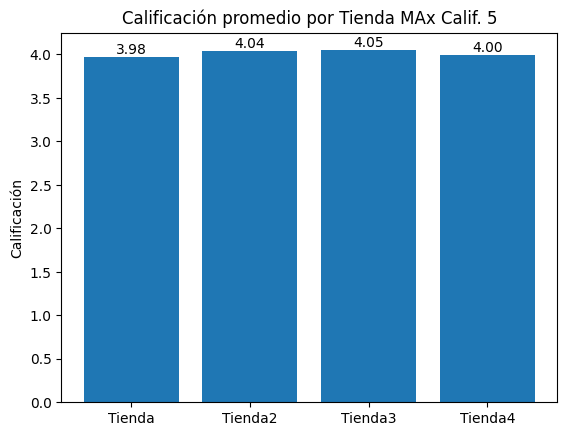

In [ ]:
# Gráfico de Barras para Calificación por Tienda
#calif_prom_tienda = [tienda["Calificación"].mean(), tienda2["Calificación"].mean(), tienda3["Calificación"].mean(), tienda4["Calificación"].mean()]
data = {'tiendas': ["Tienda", "Tienda2", "Tienda3", "Tienda4"], 'calificaciones': [tienda["Calificación"].mean(), tienda2["Calificación"].mean(), tienda3["Calificación"].mean(), tienda4["Calificación"].mean()]}
df = pd.DataFrame(data)
#plt.xlabel("Tiendas")
plt.ylabel("Calificación")
plt.title("Calificación promedio por Tienda MAx Calif. 5")
plt.bar(df['tiendas'], df['calificaciones'])
for x, y in zip(df['tiendas'], df['calificaciones']):
    plt.text(x, y, str("%.2f"%y), ha='center', va='bottom')
    #plt.text(x, y, "{:,.0f}".format(y), ha='center', va='bottom')
plt.show()

# 4. Productos más y menos vendidos

In [68]:
# Contar los productos vendidos para mostrar los mas y los menos vendidos
prod_tienda = tienda.groupby("Producto").count()["Vendedor"]
prod_tienda2 = tienda2.groupby("Producto").count()["Vendedor"]
prod_tienda3 = tienda3.groupby("Producto").count()["Vendedor"]
prod_tienda4 = tienda4.groupby("Producto").count()["Vendedor"]

print("Productos más y menos vendidos")
print()
print("Tienda: ", prod_tienda.nlargest(5))
print()
print("Tienda: ", prod_tienda.nsmallest(5))
print()
print("Tienda2: ", prod_tienda2.nlargest(5))
print()
print("Tienda2: ", prod_tienda2.nsmallest(5))
print()
print("Tienda3: ", prod_tienda3.nlargest(5))
print()
print("Tienda3: ", prod_tienda3.nsmallest(5))
print()
print("Tienda4: ", prod_tienda4.nlargest(5))
print()
print("Tienda4: ", prod_tienda4.nsmallest(5))

Productos más y menos vendidos

Tienda:  Producto
Armario                    60
Microondas                 60
TV LED UHD 4K              60
Secadora de ropa           58
Bloques de construcción    56
Name: Vendedor, dtype: int64

Tienda:  Producto
Auriculares con micrófono      33
Celular ABXY                   33
Olla de presión                35
Pandereta                      36
Ciencia de datos con Python    39
Name: Vendedor, dtype: int64

Tienda2:  Producto
Iniciando en programación    65
Microondas                   62
Batería                      61
Guitarra acústica            58
Pandereta                    58
Name: Vendedor, dtype: int64

Tienda2:  Producto
Juego de mesa      32
Impresora          34
Mesa de comedor    34
Sillón             35
Auriculares        37
Name: Vendedor, dtype: int64

Tienda3:  Producto
Kit de bancas      57
Cama king          56
Mesa de comedor    56
Mesa de noche      55
Set de ollas       55
Name: Vendedor, dtype: int64

Tienda3:  Producto
Bloque

# 5. Envío promedio por tienda

In [ ]:
# Conteo de filas, suma de Costo
# print(len(tienda), len(tienda.columns), tienda['Precio'].sum(), tienda['Costo de envío'].sum() )
print("Costo promedio de envio por cada Tienda")
print()
#print(f"Tienda: {tienda['Costo de envío'].sum()/tienda.Producto.count():,.0f}   Tienda2: {tienda2['Costo de envío'].sum()/tienda2.Producto.count():,.0f}    Tienda3: {tienda3['Costo de envío'].sum()/tienda3.Producto.count():,.0f}   Tienda4: {tienda4['Costo de envío'].sum()/tienda4.Producto.count():,.0f}")
print(f"Tienda: {tienda['Costo de envío'].mean():,.0f}   Tienda2: {tienda2['Costo de envío'].mean():,.0f}    Tienda3: {tienda3['Costo de envío'].mean():,.0f}   Tienda4: {tienda4['Costo de envío'].mean():,.0f}")

Costo promedio de envio por cada Tienda

Tienda: 26,019   Tienda2: 25,216    Tienda3: 24,806   Tienda4: 23,459


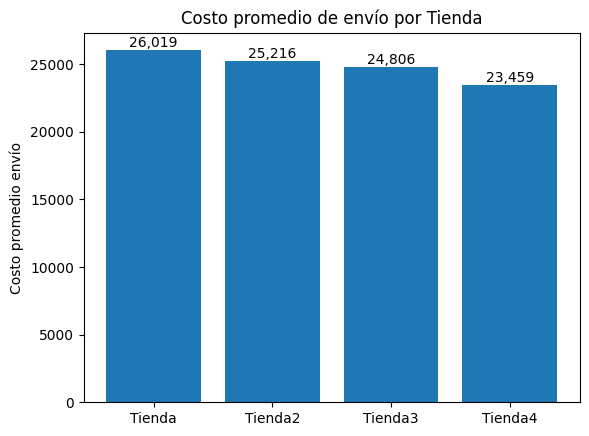

In [73]:
# Gráfico de Barras para Costo de Envío por Tienda
#costo_prom_env_tienda = [tienda['Costo de envío'].sum()/tienda.Producto.count(), tienda2['Costo de envío'].sum()/tienda2.Producto.count(), tienda3['Costo de envío'].sum()/tienda3.Producto.count(), tienda4['Costo de envío'].sum()/tienda4.Producto.count()]
data = {'tiendas': ["Tienda", "Tienda2", "Tienda3", "Tienda4"], 'costos': [tienda["Costo de envío"].mean(), tienda2["Costo de envío"].mean(), tienda3["Costo de envío"].mean(), tienda4["Costo de envío"].mean()]}
df = pd.DataFrame(data)
#print(" promerio " + str(tienda["Costo de envío"].mean))
#plt.xlabel("Tiendas")
plt.ylabel("Costo promedio envío")
plt.title("Costo promedio de envío por Tienda")
plt.bar(df['tiendas'], df['costos'])
for x, y in zip(df['tiendas'], df['costos']):
    plt.text(x, y, "{:,.0f}".format(y), ha='center', va='bottom')
plt.show()

#   6. Análisis del desempeño geográfico

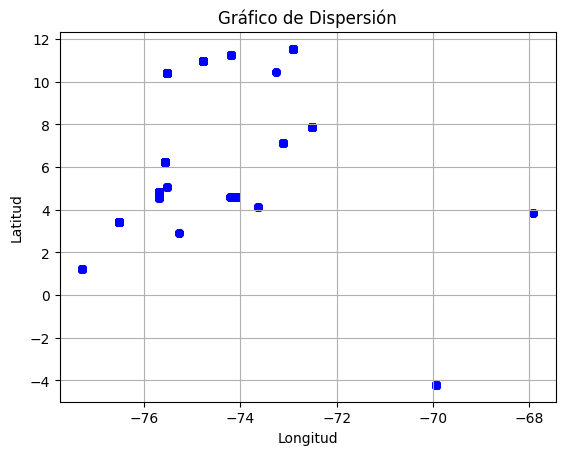

In [ ]:
#import numpy as np

# Generar datos de ejemplo
#x = np.random.rand(50)  # Coordenadas X aleatorias
#y = np.random.rand(50)  # Coordenadas Y aleatorias

# Crear el gráfico de dispersión
# plt.scatter(x=tienda.lon, y=tienda.lat, c='blue', s=30)
plt.scatter(x=tienda.lon, y=tienda.lat, c='blue', s=30)
# Agregar etiquetas y título
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Gráfico de Dispersión")

# Mostrar la grilla
plt.grid(True)

#Mostrar el gráfico
plt.show()